# Animation of ice bridge from sassie ecco model

In [18]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
from pprint import pprint
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import cmocean
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:45099")
client

<Client: 'tcp://127.0.0.1:45099' processes=8 threads=32, memory=123.95 GiB>

### Open 3D model fields

In [13]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [14]:
# open SALT zarr store
salt_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/')

# open SEA ICE AREA zarr store
ice_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/')

ffmpeg ref: https://trac.ffmpeg.org/wiki/Encode/H.264

To make an animation:

`ffmpeg -r 4 -i figname_%03d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" filename.mp4`

Break each piece down and explain:

`-r 4`: This sets the frame rate to 4 frames per second (fps). This means that the resulting video will play at 4 frames per second.

`-i figname_%03d.png`:

    -i specifies the input files.
    figname_%03d.png is a pattern that FFmpeg uses to match sequentially numbered PNG files.
        %03d tells FFmpeg to look for numbers in the filenames padded to 3 digits (e.g., figname_001.png, figname_002.png, etc.).

`-pix_fmt yuv420p`: This sets the pixel format to yuv420p, which is widely compatible with video players. It stands for:

    Y (luminance/brightness)
    UV (chrominance/color) at 4:2:0 subsampling, meaning lower color resolution, which is common for video compression.

`-vf "scale=trunc(iw/2)*2:trunc(ih/2)*2"`:

    -vf applies a video filter (in this case, the scale filter).
    "scale=trunc(iw/2)*2:trunc(ih/2)*2" resizes the input video to make sure its width (iw) and height (ih) are even numbers.
        trunc(iw/2)*2 ensures the width is divisible by 2 by truncating the division result and multiplying by 2. Similarly for the height.
        Many codecs require the video dimensions to be divisible by 2 for proper encoding.

`filename.mp4`: This is the name of the output file, which will be encoded as an MP4 video.

We want:
- 4 zero padding in filename to number each day sequentially

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

To make the resolution better and video larger:

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw*2/2)*2:trunc(ih*2/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

#### Final notes

- using png with dpi = 300 worked well
- 10 frames per second is good speed
- crf 10 seems like good quality
- can adjust scale depending on what size video you want
- I don't think having the flag `-preset slow` is doing anything noticeable...

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

## Make figure with SSS and sea ice on top, then same for SST

In [5]:
date = '2020-10-17'

In [15]:
ice_ds = (ice_zarr.sel(time=date).SIarea*100).load()
salt_ds = salt_zarr.sel(time=date).isel(k=0).SALT.load()

In [37]:
# mask out grid cells where sea ice is < 15%
ice = ice_ds.where(ice_ds>15,np.nan).isel(time=0)
sss = salt_ds.where(ice_ds<15,np.nan).isel(time=0)

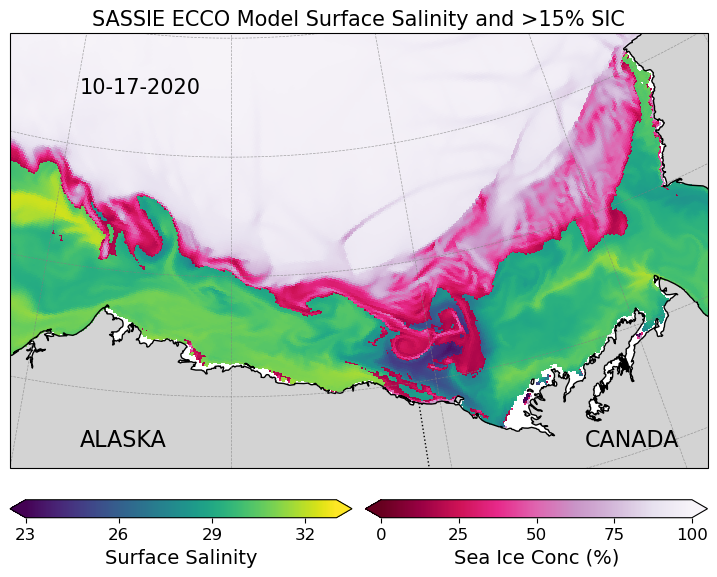

In [119]:
# date formatting
date_str = str(salt_ds.time.values)
# Extract day and month-year
date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]

# Make the figure
fig, ax = plt.subplots(figsize=(9,6),
                       subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-150)})

# Plot the DataArray
# Use transform=ccrs.PlateCarree() because XC/YC are in lon/lat
sic_cmap = ax.pcolormesh(ice.XC, ice.YC, ice, 
                    vmin=0, vmax=100, transform=ccrs.PlateCarree(), cmap='PuRd_r')

salt_cmap = ax.pcolormesh(salt_ice_mask.XC, salt_ice_mask.YC, salt_ice_mask, 
                    vmin=23,vmax=33, transform=ccrs.PlateCarree(), cmap='viridis')

# Add map features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', linewidth=1)

# Set extent roughly around the Beaufort Sea
# lat/lon bounding box: lon_min, lon_max, lat_min, lat_max
ax.set_extent([-160, -128, 68.5, 75], crs=ccrs.PlateCarree())

# Add consistent lat/lon gridlines
# Specify which latitudes and longitudes to plot
lats = np.arange(68, 78, 2)    # every 2 degrees
lons = np.arange(-160, -119, 10)  # every 10 degrees

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.5,
    color='gray',
    alpha=0.7,
    linestyle='--'
)
gl.xlocator = plt.FixedLocator(lons)
gl.ylocator = plt.FixedLocator(lats)
gl.xlabel_style = {'fontsize': 10, 'color': 'gray'}
gl.ylabel_style = {'fontsize': 10, 'color': 'gray'}


# Add text: Alaska / Canada in bottom corners
ax.text(0.1, 0.04, 'ALASKA', transform=ax.transAxes,
        fontsize=16, color='k',
        ha='left', va='bottom')
ax.text(0.96, 0.04, 'CANADA', transform=ax.transAxes,
        fontsize=16, color='k',
        ha='right', va='bottom')

plt.title("SASSIE ECCO Model Surface Salinity and >15% SIC",fontsize=15)

# Add date in upper left
ax.text(0.1, 0.9, f'{date}', transform=ax.transAxes,
        fontsize=15, color='k',
        ha='left', va='top')

# Define the positions for two horizontal colorbars at the bottom
# Format: [left, bottom, width, height] in figure coordinates (0 to 1)
cbar_ax1 = fig.add_axes([0.125, 0.05, 0.38, 0.03])  # left half
cbar_ax2 = fig.add_axes([0.52, 0.05, 0.38, 0.03])  # right half

# Create the colorbars
cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, orientation='horizontal', extend='both')
cbar1.set_label("Surface Salinity", fontsize=14)
cbar1.set_ticks([23, 26, 29, 32])

cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, orientation='horizontal', extend='both')
cbar2.set_label("Sea Ice Conc (%)", fontsize=14)
cbar2.set_ticks([0, 25, 50, 75, 100])

plt.show()

***

## Generate series of PNG images, one for each day

In [89]:
time_start = "2020-09-01"
time_end = "2020-11-30"
k_level = 0

In [106]:
ice_da = (ice_zarr.sel(time=slice(time_start,time_end)).isel(i=slice(450,1000),j=slice(0,270*2)).SIarea*100).load()
salt_da = salt_zarr.sel(time=slice(time_start,time_end)).isel(i=slice(450,1000),j=slice(0,270*2),k=k_level).SALT.load()

In [107]:
# mask out grid cells where sea ice is < 15%
ice_mask = ice_da.where(ice_da>15, np.nan)
salt_mask = salt_da.where(ice_da<15, np.nan)

In [121]:
for i in tqdm(range(len(ice_mask.time))):
    
    # pull out one day
    salt_day_da = salt_mask.isel(time=i).load()
    ice_day_da = ice_mask.isel(time=i).load()
    
    # make plot

    # date formatting
    date_str = str(salt_day_da.time.values)
    # Extract day and month-year
    date = date_str[5:10] + '-' + date_str[0:4]
    
    # Make the figure
    fig, ax = plt.subplots(figsize=(9,6),
                           subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-150)})
    
    # Plot the DataArray
    # Use transform=ccrs.PlateCarree() because XC/YC are in lon/lat
    sic_cmap = ax.pcolormesh(ice_day_da.XC, ice_day_da.YC, ice_day_da, 
                        vmin=0, vmax=100, transform=ccrs.PlateCarree(), cmap='PuRd_r')
    
    salt_cmap = ax.pcolormesh(salt_day_da.XC, salt_day_da.YC, salt_day_da, 
                        vmin=23, vmax=33, transform=ccrs.PlateCarree(), cmap='viridis')
    
    # Add map features
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', linewidth=1)
    
    # Set extent roughly around the Beaufort Sea
    # lat/lon bounding box: lon_min, lon_max, lat_min, lat_max
    ax.set_extent([-160, -128, 68.5, 75], crs=ccrs.PlateCarree())
    
    # Add consistent lat/lon gridlines
    # Specify which latitudes and longitudes to plot
    lats = np.arange(68, 78, 2)    # every 2 degrees
    lons = np.arange(-160, -119, 10)  # every 10 degrees

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.5,
        color='gray',
        alpha=0.7,
        linestyle='--'
    )
    gl.xlocator = plt.FixedLocator(lons)
    gl.ylocator = plt.FixedLocator(lats)
    gl.xlabel_style = {'fontsize': 10, 'color': 'gray'}
    gl.ylabel_style = {'fontsize': 10, 'color': 'gray'}
    
    
    # Add text: Alaska / Canada in bottom corners
    ax.text(0.1, 0.04, 'ALASKA', transform=ax.transAxes,
            fontsize=16, color='k',
            ha='left', va='bottom')
    ax.text(0.96, 0.04, 'CANADA', transform=ax.transAxes,
            fontsize=16, color='k',
            ha='right', va='bottom')
    
    plt.title("SASSIE ECCO Model Surface Salinity and Sea Ice > 15%",fontsize=15)
    
    # Add date in upper left
    ax.text(0.1, 0.9, f'{date}', transform=ax.transAxes,
            fontsize=15, color='k',
            ha='left', va='top')
    
    # Define the positions for two horizontal colorbars at the bottom
    # Format: [left, bottom, width, height] in figure coordinates (0 to 1)
    cbar_ax1 = fig.add_axes([0.125, 0.05, 0.38, 0.03])  # left half
    cbar_ax2 = fig.add_axes([0.52, 0.05, 0.38, 0.03])  # right half
    
    # Create the colorbars
    cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, orientation='horizontal', extend='both')
    cbar1.set_label("Surface Salinity", fontsize=14)
    cbar1.set_ticks([23, 26, 29, 32])
    
    cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, orientation='horizontal', extend='both')
    cbar2.set_label("Sea Ice Conc (%)", fontsize=14)
    cbar2.set_ticks([0, 25, 50, 75, 100])
    
    # save fig
    filename = f"sassie-ecco-sic-sss-beaufort-{date[-4:]}_{i:04d}.png"
    plt.savefig(f"/home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/{filename}",dpi=300,bbox_inches='tight')
    
    plt.close()
    
    # print(f'. . . saved {filename}')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 91/91 [03:13<00:00,  2.13s/it]


#### Run in terminal:

For salinity and sea ice movie:<br>
`ffmpeg -r 10 -i sassie-ecco-sic-sss-beaufort-2020_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw*2/2)*2:trunc(ih*2/2)*2" -crf 10 sassie-ecco-sic-sss-beaufort-2020.mp4`

transfer to ecco s3 bucket:<br>
`aws s3 cp ~/efs-mount-point/mzahn/sassie/HH/animation/pngs/sassie-ecco-sic-sss-beaufort-2020.mp4 s3://ecco-processed-data/SASSIE/Videos/`